# MAgent2 PyTorch MFRL Baselines

Train reference-style PyTorch MFRL baselines on MAgent2 `battle_v4`: Individual Q-Learning (`iql`), Individual Actor-Critic (`ac`), and Mean Field Q-Learning (`mfq`). The algorithm/network code follows `mfrl_pytorch-master`; this notebook uses the project helper for synchronous vectorized rollout collection.

In [1]:
from pathlib import Path
import sys
import torch
import pandas as pd


def find_repo_root(start=Path.cwd()):
    for path in (start, *start.parents):
        if (path / "discrete_action_space").is_dir() and (path / "requirements.txt").exists():
            return path
    raise RuntimeError("Could not find the SRE-DQN repo root from the current notebook directory.")


ROOT = find_repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from discrete_action_space.mean_field_dsrq.mfrl_baselines import (
    DEFAULT_MFRL_TASK_CONFIG,
    train_mfrl_baseline,
)
from discrete_action_space.mean_field_dsrq.notebook_utils import (
    baseline_rollout_video_from_notebook,
    find_latest_mfrl_run,
    plot_mfrl_baseline_training_curves,
)

TASK_CONFIG = {
    **DEFAULT_MFRL_TASK_CONFIG,
    "env_name": "battle_v4",
    "map_size": 40,
    "max_cycles": 400,
}
TARGET_EPISODES = 2000
NUM_ENVS = 1
MAX_STEPS = 50
REWARD_LOG_INTERVAL = 100
MAX_TRAIN_BATCHES_PER_UPDATE = None
MAX_POLICY_SAMPLES_PER_UPDATE = None
AC_UPDATE_REPEATS = None
SMOOTHING_WINDOW = 20
SEED = 42
SAVE_FOLDER = ROOT / "discrete_action_space" / "mean_field_dsrq" / "runs" / "mfrl_baselines"
SAVE_FOLDER.mkdir(parents=True, exist_ok=True)
BASELINE_RUN_DIRS = {}
for algorithm in ("iql", "ac", "mfq"):
    try:
        BASELINE_RUN_DIRS[algorithm] = find_latest_mfrl_run(algorithm, SAVE_FOLDER)
    except FileNotFoundError:
        pass
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

common_kwargs = dict(
    task_config=TASK_CONFIG,
    target_episodes=TARGET_EPISODES,
    num_envs=NUM_ENVS,
    seed=SEED,
    save_folder=SAVE_FOLDER,
    device=DEVICE,
    reward_log_interval=REWARD_LOG_INTERVAL,
    max_train_batches_per_update=MAX_TRAIN_BATCHES_PER_UPDATE,
    max_policy_samples_per_update=MAX_POLICY_SAMPLES_PER_UPDATE,
    ac_update_repeats=AC_UPDATE_REPEATS,
)
BASELINE_RUN_DIRS
print(DEVICE)


cuda


## IQL

In [2]:
iql_result = train_mfrl_baseline("iql", **common_kwargs)


IQL episodes:   0%|          | 0/2000 [00:00<?, ?ep/s]

[iql] episodes=100/2000 mean_main_reward=-728.788 mean_opponent_reward=-727.803
[iql] episodes=200/2000 mean_main_reward=-70.952 mean_opponent_reward=-77.967
[iql] episodes=300/2000 mean_main_reward=-1.684 mean_opponent_reward=-2.132
[iql] episodes=400/2000 mean_main_reward=-7.315 mean_opponent_reward=3.766
[iql] episodes=500/2000 mean_main_reward=27.521 mean_opponent_reward=28.771
[iql] episodes=600/2000 mean_main_reward=40.974 mean_opponent_reward=42.566
[iql] episodes=700/2000 mean_main_reward=59.234 mean_opponent_reward=65.851
[iql] episodes=800/2000 mean_main_reward=88.534 mean_opponent_reward=96.461
[iql] episodes=900/2000 mean_main_reward=113.658 mean_opponent_reward=116.400
[iql] episodes=1000/2000 mean_main_reward=135.252 mean_opponent_reward=137.706
[iql] episodes=1100/2000 mean_main_reward=154.236 mean_opponent_reward=149.746
[iql] episodes=1200/2000 mean_main_reward=176.692 mean_opponent_reward=175.290
[iql] episodes=1300/2000 mean_main_reward=198.513 mean_opponent_reward=1

Saved training curves to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mfrl_baselines/iql_battle_v4_seed42_26_06_06-13_31_34/training_reward_wins_and_kills.png


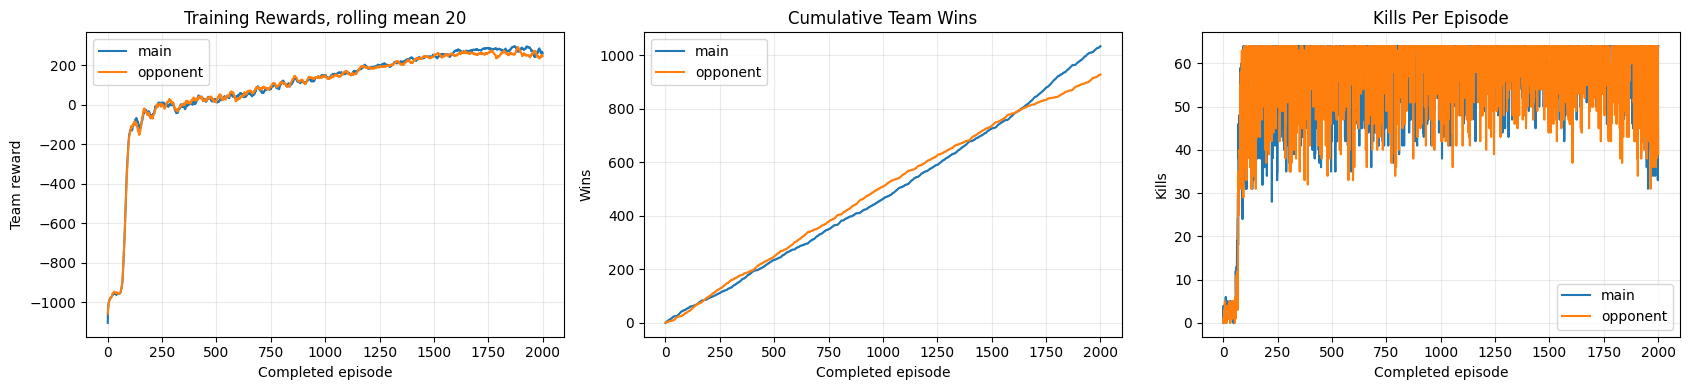

In [3]:
_ = plot_mfrl_baseline_training_curves(iql_result, smoothing_window=SMOOTHING_WINDOW)


## IQL Evaluation Rollout

In [4]:
baseline_rollout_video_from_notebook(
    iql_result,
    max_steps=MAX_STEPS,
    fps=8,
    deterministic=True,
    title="IQL evaluation rollout",
)


/home/wowthecoder/SRE-DQN/venv/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


## AC

In [2]:
ac_result = train_mfrl_baseline("ac", **common_kwargs)


AC episodes:   0%|          | 0/2000 [00:00<?, ?ep/s]

[ac] episodes=100/2000 mean_main_reward=-569.342 mean_opponent_reward=-563.159
[ac] episodes=200/2000 mean_main_reward=-511.955 mean_opponent_reward=-511.495
[ac] episodes=300/2000 mean_main_reward=-510.986 mean_opponent_reward=-510.145
[ac] episodes=400/2000 mean_main_reward=-509.589 mean_opponent_reward=-511.000
[ac] episodes=500/2000 mean_main_reward=-501.259 mean_opponent_reward=-503.642
[ac] episodes=600/2000 mean_main_reward=-272.221 mean_opponent_reward=-265.961
[ac] episodes=700/2000 mean_main_reward=199.409 mean_opponent_reward=201.849
[ac] episodes=800/2000 mean_main_reward=226.680 mean_opponent_reward=234.786
[ac] episodes=900/2000 mean_main_reward=255.830 mean_opponent_reward=269.084
[ac] episodes=1000/2000 mean_main_reward=271.871 mean_opponent_reward=277.903
[ac] episodes=1100/2000 mean_main_reward=274.154 mean_opponent_reward=284.092
[ac] episodes=1200/2000 mean_main_reward=282.475 mean_opponent_reward=288.408
[ac] episodes=1300/2000 mean_main_reward=281.454 mean_opponen

Saved training curves to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mfrl_baselines/ac_battle_v4_seed42_26_06_06-15_19_57/training_reward_wins_and_kills.png


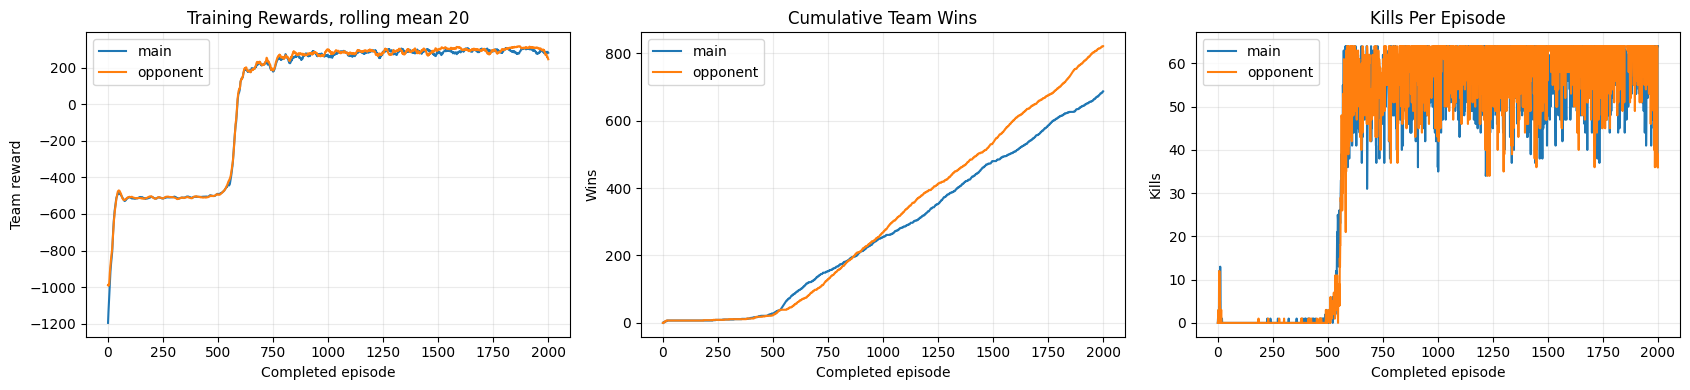

In [3]:
_ = plot_mfrl_baseline_training_curves(ac_result, smoothing_window=SMOOTHING_WINDOW)


## AC Evaluation Rollout

In [4]:
baseline_rollout_video_from_notebook(
    ac_result,
    max_steps=MAX_STEPS,
    fps=8,
    deterministic=True,
    title="AC evaluation rollout",
)


/home/wowthecoder/SRE-DQN/venv/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


## MFQ

In [2]:
mfq_result = train_mfrl_baseline("mfq", **common_kwargs)


MFQ episodes:   0%|          | 0/2000 [00:00<?, ?ep/s]

[mfq] episodes=100/2000 mean_main_reward=51.311 mean_opponent_reward=106.076
[mfq] episodes=200/2000 mean_main_reward=226.460 mean_opponent_reward=248.476
[mfq] episodes=300/2000 mean_main_reward=261.320 mean_opponent_reward=254.635
[mfq] episodes=400/2000 mean_main_reward=259.033 mean_opponent_reward=270.770
[mfq] episodes=500/2000 mean_main_reward=249.088 mean_opponent_reward=249.119
[mfq] episodes=600/2000 mean_main_reward=233.076 mean_opponent_reward=245.714
[mfq] episodes=700/2000 mean_main_reward=242.507 mean_opponent_reward=233.458
[mfq] episodes=800/2000 mean_main_reward=247.455 mean_opponent_reward=241.153
[mfq] episodes=900/2000 mean_main_reward=255.566 mean_opponent_reward=250.978
[mfq] episodes=1000/2000 mean_main_reward=269.318 mean_opponent_reward=259.729
[mfq] episodes=1100/2000 mean_main_reward=265.523 mean_opponent_reward=266.810
[mfq] episodes=1200/2000 mean_main_reward=258.788 mean_opponent_reward=263.891
[mfq] episodes=1300/2000 mean_main_reward=256.158 mean_opponen

Saved training curves to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mfrl_baselines/mfq_battle_v4_seed42_26_06_06-21_52_18/training_reward_wins_and_kills.png


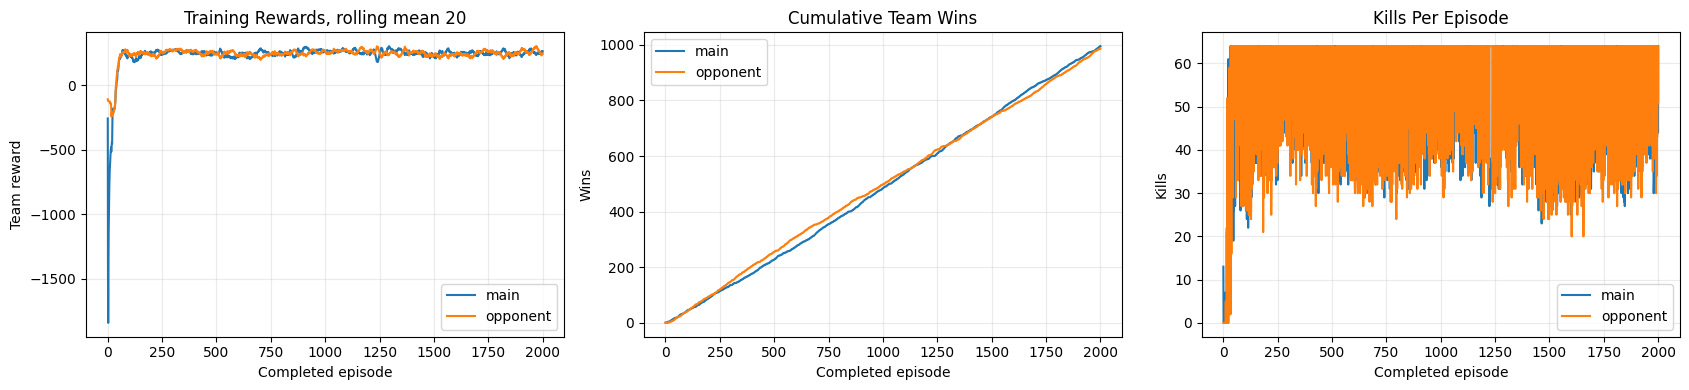

In [3]:
_ = plot_mfrl_baseline_training_curves(mfq_result, smoothing_window=SMOOTHING_WINDOW)


## MFQ Evaluation Rollout

In [4]:
baseline_rollout_video_from_notebook(
    mfq_result,
    max_steps=MAX_STEPS,
    fps=8,
    deterministic=True,
    title="MFQ evaluation rollout",
)


/home/wowthecoder/SRE-DQN/venv/lib/python3.12/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


## Comparison

In [8]:
baseline_results = [iql_result, ac_result, mfq_result]
pd.DataFrame([
    {
        "algorithm": result["algorithm"],
        "completed_episodes": result["completed_episodes"],
        "num_envs": result["num_envs"],
        "device": result["device"],
        "main_win_rate": result["summary"].get("main_win_rate"),
        "opponent_win_rate": result["summary"].get("opponent_win_rate"),
        "tie_rate": result["summary"].get("tie_rate"),
        "run_dir": result["run_dir"],
    }
    for result in baseline_results
])


NameError: name 'iql_result' is not defined